# QuickCart Stockout Risk — End-to-End ML Project

Load → clean → join → EDA → feature engineering → time split → baseline/Logistic Regression/Random Forest → evaluation → conclusions.

In [ ]:
# Run the complete pipeline used to create this project.
# All source CSVs are in /mnt/data/quickcart/events.
exec(open("/mnt/data/quickcart/build_project.py", encoding="utf-8").read())


## Modeling notes

Use the chronological split (Oct 1–23 train; Oct 24–30 test) to avoid row-level leakage. Pay special attention to Imminent recall. `days_of_cover` is a powerful predictor because it is directly related to the business definition of the target; in production, verify that it is available at prediction time and does not contain future information.

In [1]:
import pandas as pd

stores = pd.read_csv("dim_stores.csv")
skus = pd.read_csv("dim_skus.csv")
suppliers = pd.read_csv("dim_suppliers.csv")
events = pd.read_csv("dim_events.csv")
inventory = pd.read_csv("fact_inventory_daily.csv")

print("Stores:", stores.shape)
print("SKUs:", skus.shape)
print("Suppliers:", suppliers.shape)
print("Events:", events.shape)
print("Inventory:", inventory.shape)

Stores: (12, 8)
SKUs: (60, 9)
Suppliers: (15, 6)
Events: (30, 5)
Inventory: (21600, 16)


In [2]:
# STEP 2: DATA CLEANING

# Check missing values
print("Missing values in each table:\n")

print("STORES")
print(stores.isnull().sum())

print("\nSKUS")
print(skus.isnull().sum())

print("\nSUPPLIERS")
print(suppliers.isnull().sum())

print("\nEVENTS")
print(events.isnull().sum())

print("\nINVENTORY")
print(inventory.isnull().sum())

Missing values in each table:

STORES
store_id                 0
city                     0
city_display             0
city_tier                0
store_size               0
sqft                     0
opened_year              0
baseline_daily_orders    0
dtype: int64

SKUS
sku_id              0
sku_name            0
category            0
unit_price_inr      0
shelf_life_days     0
is_perishable       0
festive_relevant    0
popularity_tier     0
supplier_id         0
dtype: int64

SUPPLIERS
supplier_id                0
supplier_name              0
categories_supplied        0
reliability_score          3
base_lead_time_days        0
lead_time_variance_days    0
dtype: int64

EVENTS
date                         0
event_name                   0
event_type                   0
demand_multiplier_festive    0
demand_multiplier_other      0
dtype: int64

INVENTORY
date                           0
store_id                       0
sku_id                         0
supplier_id                    0

In [3]:
# STEP 2: CLEANING THE DATA

# 1. Convert date column to datetime
inventory["date"] = pd.to_datetime(inventory["date"])
events["date"] = pd.to_datetime(events["date"])

# 2. Clean supplier reliability
# Convert possible text values such as N/A into missing values
suppliers["reliability_score"] = pd.to_numeric(
    suppliers["reliability_score"],
    errors="coerce"
)

# Fill the 3 missing reliability values with median
median_reliability = suppliers["reliability_score"].median()

suppliers["reliability_score"] = suppliers["reliability_score"].fillna(
    median_reliability
)

# 3. Clean city display names
stores["city_display"] = (
    stores["city_display"]
    .astype(str)
    .str.strip()
    .str.title()
)

# 4. Check duplicates
print("Duplicate rows:")

print("Stores:", stores.duplicated().sum())
print("SKUs:", skus.duplicated().sum())
print("Suppliers:", suppliers.duplicated().sum())
print("Events:", events.duplicated().sum())
print("Inventory:", inventory.duplicated().sum())

# 5. Final missing-value check
print("\nMissing supplier reliability:")
print(suppliers["reliability_score"].isnull().sum())

print("\nMissing actual lead time:")
print(inventory["lead_time_days_actual"].isnull().sum())

print("\nCleaning completed successfully! ✅")

Duplicate rows:
Stores: 0
SKUs: 0
Suppliers: 0
Events: 0
Inventory: 0

Missing supplier reliability:
0

Missing actual lead time:
19899

Cleaning completed successfully! ✅


In [5]:
# STEP 3: JOIN ALL TABLES - FIXED

master = (
    inventory
    .merge(
        stores,
        on="store_id",
        how="left"
    )
    .merge(
        skus.drop(columns=["supplier_id"]),
        on="sku_id",
        how="left"
    )
    .merge(
        suppliers,
        on="supplier_id",
        how="left"
    )
    .merge(
        events,
        on="date",
        how="left"
    )
)

print("Master dataset shape:", master.shape)

print("\nFirst 5 rows:")
display(master.head())

print("\nMissing values after joining:")
print(master.isnull().sum().sort_values(ascending=False).head(10))

Master dataset shape: (21600, 39)

First 5 rows:


,date,store_id,sku_id,supplier_id,opening_stock,units_demanded,units_sold,closing_stock,reorder_point,reorder_placed,...,popularity_tier,supplier_name,categories_supplied,reliability_score,base_lead_time_days,lead_time_variance_days,event_name,event_type,demand_multiplier_festive,demand_multiplier_other
0,2026-10-01,ST01,SKU001,SUP11,159.9,15,15.0,144.9,36.4,N,...,Low,Coastal Foods Pvt Ltd,"Snacks, Fruits & Vegetables",0.83,1,2.5,Regular Day,none,1.0,1.0
1,2026-10-02,ST01,SKU001,SUP11,144.9,10,10.0,134.9,36.4,N,...,Low,Coastal Foods Pvt Ltd,"Snacks, Fruits & Vegetables",0.83,1,2.5,Regular Day,none,1.0,1.0
2,2026-10-03,ST01,SKU001,SUP11,134.9,15,15.0,119.9,36.4,N,...,Low,Coastal Foods Pvt Ltd,"Snacks, Fruits & Vegetables",0.83,1,2.5,Regular Day,none,1.0,1.0
3,2026-10-04,ST01,SKU001,SUP11,119.9,10,10.0,109.9,36.4,N,...,Low,Coastal Foods Pvt Ltd,"Snacks, Fruits & Vegetables",0.83,1,2.5,Regular Day,none,1.0,1.0
4,2026-10-05,ST01,SKU001,SUP11,109.9,9,9.0,100.9,36.4,N,...,Low,Coastal Foods Pvt Ltd,"Snacks, Fruits & Vegetables",0.83,1,2.5,Regular Day,none,1.0,1.0



Missing values after joining:
lead_time_days_actual    19899
store_id                     0
date                         0
supplier_id                  0
opening_stock                0
units_demanded               0
sku_id                       0
units_sold                   0
closing_stock                0
reorder_placed               0
dtype: int64


Stockout Risk Distribution:
stockout_risk
Safe        14131
At-Risk      5186
Imminent     2283
Name: count, dtype: int64

Percentage Distribution:
stockout_risk
Safe        65.42
At-Risk     24.01
Imminent    10.57
Name: proportion, dtype: float64


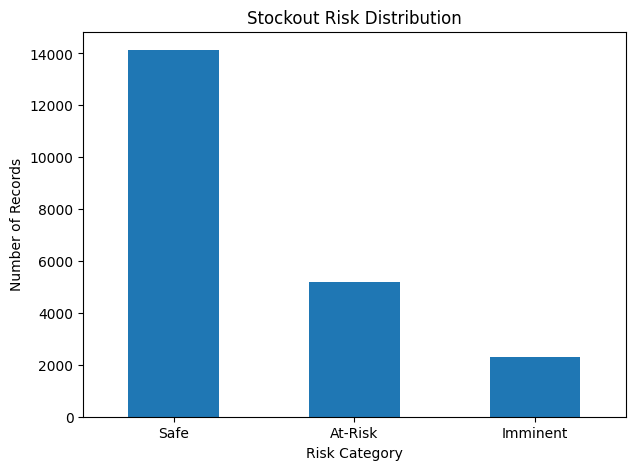

In [6]:
# STEP 4: EXPLORATORY DATA ANALYSIS (EDA)

import matplotlib.pyplot as plt

# 1. Stockout Risk Distribution
print("Stockout Risk Distribution:")
print(master["stockout_risk"].value_counts())

print("\nPercentage Distribution:")
print(
    (master["stockout_risk"].value_counts(normalize=True) * 100)
    .round(2)
)

# Plot
master["stockout_risk"].value_counts().plot(
    kind="bar",
    figsize=(7, 5)
)

plt.title("Stockout Risk Distribution")
plt.xlabel("Risk Category")
plt.ylabel("Number of Records")
plt.xticks(rotation=0)
plt.show()

Imminent Stockout Rate:
is_festival_week
N     9.51
Y    23.31
Name: stockout_risk, dtype: float64


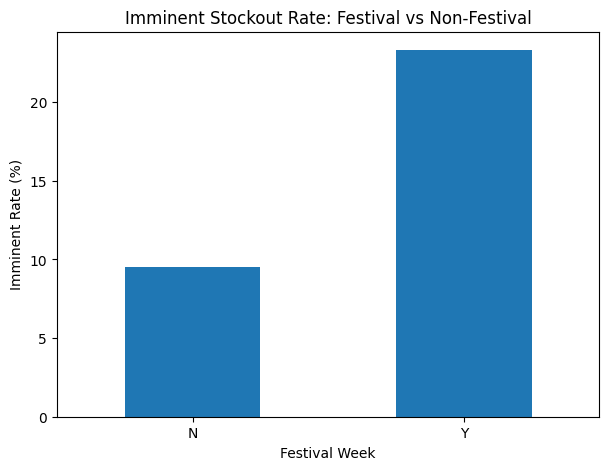

In [7]:
# Festival vs Non-Festival Stockout Risk

festival_risk = (
    master.groupby("is_festival_week")["stockout_risk"]
    .apply(lambda x: (x == "Imminent").mean() * 100)
)

print("Imminent Stockout Rate:")
print(festival_risk.round(2))

# Plot
festival_risk.plot(
    kind="bar",
    figsize=(7, 5)
)

plt.title("Imminent Stockout Rate: Festival vs Non-Festival")
plt.xlabel("Festival Week")
plt.ylabel("Imminent Rate (%)")
plt.xticks(rotation=0)
plt.show()

Imminent Stockout Rate by Supplier Reliability:
reliability_score
0.630    27.04
0.720    26.94
0.660    18.47
0.670    15.00
0.730    13.40
0.700     8.03
0.725     7.16
0.930     4.67
0.920     3.52
0.830     3.26
0.910     2.99
Name: stockout_risk, dtype: float64


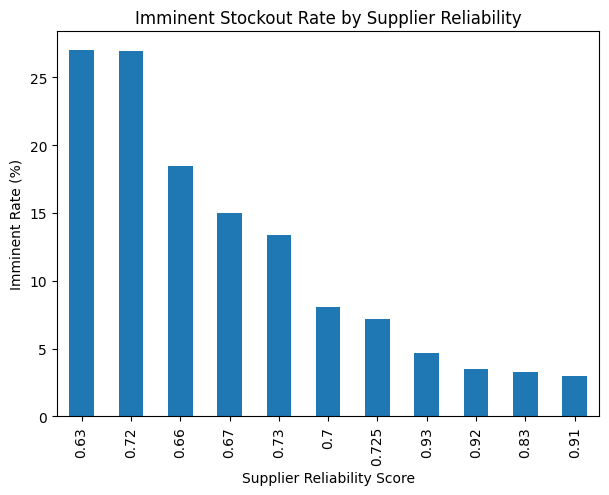

In [9]:
# Supplier Reliability vs Stockout Risk

supplier_risk = (
    master.groupby("reliability_score")["stockout_risk"]
    .apply(lambda x: (x == "Imminent").mean() * 100)
    .sort_values(ascending=False)
)

print("Imminent Stockout Rate by Supplier Reliability:")
print(supplier_risk.round(2))

supplier_risk.plot(
    kind="bar",
    figsize=(7, 5)
)

plt.title("Imminent Stockout Rate by Supplier Reliability")
plt.xlabel("Supplier Reliability Score")
plt.ylabel("Imminent Rate (%)")
plt.show()

In [11]:
print("Reliability score range:")
print(master["reliability_score"].min())
print(master["reliability_score"].max())

print("\nUnique reliability scores:")
print(sorted(master["reliability_score"].unique()))

Reliability score range:
0.63
0.93

Unique reliability scores:
[np.float64(0.63), np.float64(0.66), np.float64(0.67), np.float64(0.7), np.float64(0.72), np.float64(0.725), np.float64(0.73), np.float64(0.83), np.float64(0.91), np.float64(0.92), np.float64(0.93)]


Reliability Category Counts:
reliability_category
Low     15840
High     4320
Mid      1440
Name: count, dtype: int64

Imminent Stockout Rate:
reliability_category
Low     13.07
Mid      3.26
High     3.82
Name: stockout_risk, dtype: float64


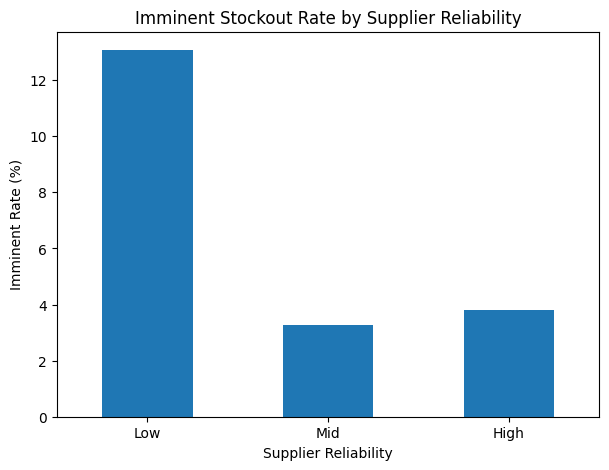

In [12]:
# Fix supplier reliability categories

master["reliability_category"] = pd.cut(
    master["reliability_score"],
    bins=[0.60, 0.75, 0.85, 1.00],
    labels=["Low", "Mid", "High"],
    include_lowest=True
)

# Check category counts
print("Reliability Category Counts:")
print(master["reliability_category"].value_counts())

# Calculate Imminent stockout rate
supplier_risk = (
    master.groupby("reliability_category", observed=False)["stockout_risk"]
    .apply(lambda x: (x == "Imminent").mean() * 100)
)

print("\nImminent Stockout Rate:")
print(supplier_risk.round(2))

# Plot
supplier_risk.plot(
    kind="bar",
    figsize=(7, 5)
)

plt.title("Imminent Stockout Rate by Supplier Reliability")
plt.xlabel("Supplier Reliability")
plt.ylabel("Imminent Rate (%)")
plt.xticks(rotation=0)
plt.show()

Imminent Stockout Rate:
is_perishable
N     9.30
Y    12.77
Name: stockout_risk, dtype: float64


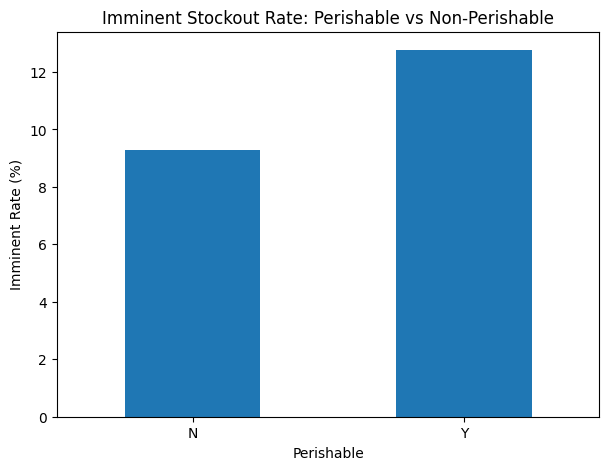

In [13]:
# Perishable vs Non-Perishable Stockout Risk

perishable_risk = (
    master.groupby("is_perishable")["stockout_risk"]
    .apply(lambda x: (x == "Imminent").mean() * 100)
)

print("Imminent Stockout Rate:")
print(perishable_risk.round(2))

# Plot
perishable_risk.plot(
    kind="bar",
    figsize=(7, 5)
)

plt.title("Imminent Stockout Rate: Perishable vs Non-Perishable")
plt.xlabel("Perishable")
plt.ylabel("Imminent Rate (%)")
plt.xticks(rotation=0)
plt.show()

In [14]:
# STEP 5.1: TIME FEATURES

master["day_of_week"] = master["date"].dt.dayofweek
master["day_of_month"] = master["date"].dt.day
master["is_weekend"] = (master["day_of_week"] >= 5).astype(int)

print("Time features created successfully! ✅")

display(
    master[
        ["date", "day_of_week", "day_of_month", "is_weekend"]
    ].head(10)
)

Time features created successfully! ✅


,date,day_of_week,day_of_month,is_weekend
0,2026-10-01,3,1,0
1,2026-10-02,4,2,0
2,2026-10-03,5,3,1
3,2026-10-04,6,4,1
4,2026-10-05,0,5,0
5,2026-10-06,1,6,0
6,2026-10-07,2,7,0
7,2026-10-08,3,8,0
8,2026-10-09,4,9,0
9,2026-10-10,5,10,1


In [16]:
print(master.columns.tolist())

['date', 'store_id', 'sku_id', 'supplier_id', 'opening_stock', 'units_demanded', 'units_sold', 'closing_stock', 'reorder_point', 'reorder_placed', 'lead_time_days_expected', 'lead_time_days_actual', 'sales_velocity_7d', 'days_of_cover', 'is_festival_week', 'stockout_risk', 'city', 'city_display', 'city_tier', 'store_size', 'sqft', 'opened_year', 'baseline_daily_orders', 'sku_name', 'category', 'unit_price_inr', 'shelf_life_days', 'is_perishable', 'festive_relevant', 'popularity_tier', 'supplier_name', 'categories_supplied', 'reliability_score', 'base_lead_time_days', 'lead_time_variance_days', 'event_name', 'event_type', 'demand_multiplier_festive', 'demand_multiplier_other', 'reliability_category', 'day_of_week', 'day_of_month', 'is_weekend']


In [18]:
# STEP 5.2: INVENTORY FEATURES

# Difference between closing stock and reorder point
master["reorder_gap"] = (
    master["closing_stock"] - master["reorder_point"]
)

# Compare days of stock cover with expected lead time
master["days_of_cover_ratio"] = (
    master["days_of_cover"] /
    master["lead_time_days_expected"].replace(0, 1)
)

print("Inventory features created successfully! ✅")

display(
    master[
        [
            "closing_stock",
            "reorder_point",
            "days_of_cover",
            "lead_time_days_expected",
            "reorder_gap",
            "days_of_cover_ratio"
        ]
    ].head(10)
)

Inventory features created successfully! ✅


,closing_stock,reorder_point,days_of_cover,lead_time_days_expected,reorder_gap,days_of_cover_ratio
0,144.9,36.4,9.66,1,108.5,9.66
1,134.9,36.4,10.79,1,98.5,10.79
2,119.9,36.4,8.99,1,83.5,8.99
3,109.9,36.4,8.79,1,73.5,8.79
4,100.9,36.4,8.55,1,64.5,8.55
5,88.9,36.4,7.52,1,52.5,7.52
6,79.9,36.4,6.99,1,43.5,6.99
7,66.9,36.4,6.01,1,30.5,6.01
8,54.9,36.4,4.81,1,18.5,4.81
9,41.9,36.4,3.76,1,5.5,3.76


In [19]:
# STEP 5.3: RECENT REORDER HISTORY

# Sort by store, SKU and date
master = master.sort_values(
    ["store_id", "sku_id", "date"]
).reset_index(drop=True)

# Number of days since the previous reorder
master["last_reorder_date"] = (
    master["date"]
    .where(master["reorder_placed"] == 1)
    .groupby([master["store_id"], master["sku_id"]])
    .ffill()
)

master["days_since_reorder"] = (
    master["date"] - master["last_reorder_date"]
).dt.days

# Fill records before the first reorder
master["days_since_reorder"] = (
    master["days_since_reorder"].fillna(999)
)

# Recent reorder indicator: reorder within last 7 days
master["recent_reorder_7d"] = (
    master["days_since_reorder"] <= 7
).astype(int)

print("Recent reorder features created successfully! ✅")

display(
    master[
        [
            "date",
            "store_id",
            "sku_id",
            "reorder_placed",
            "days_since_reorder",
            "recent_reorder_7d"
        ]
    ].head(15)
)

Recent reorder features created successfully! ✅


,date,store_id,sku_id,reorder_placed,days_since_reorder,recent_reorder_7d
0,2026-10-01,ST01,SKU001,N,999.0,0
1,2026-10-02,ST01,SKU001,N,999.0,0
2,2026-10-03,ST01,SKU001,N,999.0,0
3,2026-10-04,ST01,SKU001,N,999.0,0
4,2026-10-05,ST01,SKU001,N,999.0,0
5,2026-10-06,ST01,SKU001,N,999.0,0
6,2026-10-07,ST01,SKU001,N,999.0,0
7,2026-10-08,ST01,SKU001,N,999.0,0
8,2026-10-09,ST01,SKU001,N,999.0,0
9,2026-10-10,ST01,SKU001,N,999.0,0


In [20]:
# STEP 5.4: PREPARE ML DATASET

# Target variable
y = master["stockout_risk"]

# Features
X = master[
    [
        "closing_stock",
        "units_demanded",
        "units_sold",
        "reorder_point",
        "lead_time_days_expected",
        "sales_velocity_7d",
        "days_of_cover",
        "reorder_gap",
        "days_of_cover_ratio",
        "recent_reorder_7d",
        "is_festival_week",
        "is_perishable",
        "festive_relevant",
        "unit_price_inr",
        "shelf_life_days",
        "reliability_score",
        "lead_time_variance_days",
        "day_of_week",
        "day_of_month",
        "is_weekend"
    ]
].copy()

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

print("\nTarget distribution:")
print(y.value_counts())

print("\nMissing values in features:")
print(X.isnull().sum().sort_values(ascending=False).head())

Feature shape: (21600, 20)
Target shape: (21600,)

Target distribution:
stockout_risk
Safe        14131
At-Risk      5186
Imminent     2283
Name: count, dtype: int64

Missing values in features:
closing_stock              0
units_demanded             0
units_sold                 0
reorder_point              0
lead_time_days_expected    0
dtype: int64


In [22]:
print("Minimum date:", master["date"].min())
print("Maximum date:", master["date"].max())

Minimum date: 2026-10-01 00:00:00
Maximum date: 2026-10-30 00:00:00


In [23]:
print(master["date"].dt.date.unique()[:10])

[datetime.date(2026, 10, 1) datetime.date(2026, 10, 2)
 datetime.date(2026, 10, 3) datetime.date(2026, 10, 4)
 datetime.date(2026, 10, 5) datetime.date(2026, 10, 6)
 datetime.date(2026, 10, 7) datetime.date(2026, 10, 8)
 datetime.date(2026, 10, 9) datetime.date(2026, 10, 10)]


In [24]:
# STEP 6: CORRECT TIME-BASED TRAIN / TEST SPLIT

# Training: Oct 1 - Oct 23, 2026
# Testing: Oct 24 - Oct 30, 2026

train_mask = master["date"] < "2026-10-24"
test_mask = master["date"] >= "2026-10-24"

X_train = X.loc[train_mask]
X_test = X.loc[test_mask]

y_train = y.loc[train_mask]
y_test = y.loc[test_mask]

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

print("\nTraining target distribution:")
print(y_train.value_counts())

print("\nTesting target distribution:")
print(y_test.value_counts())

Training data: (16560, 20)
Testing data: (5040, 20)

Training target distribution:
stockout_risk
Safe        10992
At-Risk      4060
Imminent     1508
Name: count, dtype: int64

Testing target distribution:
stockout_risk
Safe        3139
At-Risk     1126
Imminent     775
Name: count, dtype: int64


In [25]:
# STEP 7: MAJORITY CLASS BASELINE

from sklearn.metrics import accuracy_score, classification_report

# Find most common class in training data
majority_class = y_train.mode()[0]

# Predict the same class for every test record
y_pred_baseline = [majority_class] * len(y_test)

print("Majority class:", majority_class)

print("\nBaseline Accuracy:")
print(round(accuracy_score(y_test, y_pred_baseline) * 100, 2), "%")

print("\nBaseline Classification Report:")
print(
    classification_report(
        y_test,
        y_pred_baseline,
        zero_division=0
    )
)


Majority class: Safe

Baseline Accuracy:
62.28 %

Baseline Classification Report:
              precision    recall  f1-score   support

     At-Risk       0.00      0.00      0.00      1126
    Imminent       0.00      0.00      0.00       775
        Safe       0.62      1.00      0.77      3139

    accuracy                           0.62      5040
   macro avg       0.21      0.33      0.26      5040
weighted avg       0.39      0.62      0.48      5040



In [27]:
# STEP 8.1: CHECK DATA TYPES

print(X.dtypes)

closing_stock              float64
units_demanded               int64
units_sold                 float64
reorder_point              float64
lead_time_days_expected      int64
sales_velocity_7d          float64
days_of_cover              float64
reorder_gap                float64
days_of_cover_ratio        float64
recent_reorder_7d            int64
is_festival_week            object
is_perishable               object
festive_relevant            object
unit_price_inr             float64
shelf_life_days              int64
reliability_score          float64
lead_time_variance_days    float64
day_of_week                  int32
day_of_month                 int32
is_weekend                   int64
dtype: object


In [28]:
# STEP 5.5: ENCODE Y/N COLUMNS

categorical_cols = [
    "is_festival_week",
    "is_perishable",
    "festive_relevant"
]

for col in categorical_cols:
    X[col] = X[col].map({
        "Y": 1,
        "N": 0
    })

# Check the result
print(X.dtypes)

print("\nMissing values after encoding:")
print(X.isnull().sum())

closing_stock              float64
units_demanded               int64
units_sold                 float64
reorder_point              float64
lead_time_days_expected      int64
sales_velocity_7d          float64
days_of_cover              float64
reorder_gap                float64
days_of_cover_ratio        float64
recent_reorder_7d            int64
is_festival_week             int64
is_perishable                int64
festive_relevant             int64
unit_price_inr             float64
shelf_life_days              int64
reliability_score          float64
lead_time_variance_days    float64
day_of_week                  int32
day_of_month                 int32
is_weekend                   int64
dtype: object

Missing values after encoding:
closing_stock              0
units_demanded             0
units_sold                 0
reorder_point              0
lead_time_days_expected    0
sales_velocity_7d          0
days_of_cover              0
reorder_gap                0
days_of_cover_ratio   

In [29]:
X_train = X.loc[train_mask]
X_test = X.loc[test_mask]

y_train = y.loc[train_mask]
y_test = y.loc[test_mask]

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

X_train: (16560, 20)
X_test: (5040, 20)


In [30]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

logistic_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=42
    ))
])

# Train
logistic_model.fit(X_train, y_train)

# Predict
y_pred_logistic = logistic_model.predict(X_test)

# Accuracy
print("Logistic Regression Accuracy:",
      accuracy_score(y_test, y_pred_logistic))

# Detailed report
print("\nClassification Report:")
print(classification_report(y_test, y_pred_logistic))

Logistic Regression Accuracy: 0.9152777777777777

Classification Report:
              precision    recall  f1-score   support

     At-Risk       0.87      0.72      0.79      1126
    Imminent       0.71      0.89      0.79       775
        Safe       0.99      0.99      0.99      3139

    accuracy                           0.92      5040
   macro avg       0.86      0.87      0.86      5040
weighted avg       0.92      0.92      0.92      5040



In [31]:
# STEP 6: RANDOM FOREST

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

random_forest = RandomForestClassifier(
    n_estimators=300,
    max_depth=12,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

# Train
random_forest.fit(X_train, y_train)

# Predict
y_pred_rf = random_forest.predict(X_test)

# Accuracy
print("Random Forest Accuracy:",
      accuracy_score(y_test, y_pred_rf))

# Detailed report
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

Random Forest Accuracy: 0.9418650793650793

Classification Report:
              precision    recall  f1-score   support

     At-Risk       0.84      0.91      0.88      1126
    Imminent       0.86      0.75      0.80       775
        Safe       1.00      1.00      1.00      3139

    accuracy                           0.94      5040
   macro avg       0.90      0.89      0.89      5040
weighted avg       0.94      0.94      0.94      5040



In [32]:
# STEP 7: RANDOM FOREST FEATURE IMPORTANCE

import pandas as pd
import matplotlib.pyplot as plt

feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": random_forest.feature_importances_
})

feature_importance = feature_importance.sort_values(
    "Importance",
    ascending=False
)

print("Top 10 Important Features:")
display(feature_importance.head(10))

Top 10 Important Features:


,Feature,Importance
6,days_of_cover,0.256150
8,days_of_cover_ratio,0.235278
7,reorder_gap,0.223102
0,closing_stock,0.065645
15,reliability_score,0.033300
5,sales_velocity_7d,0.027487
4,lead_time_days_expected,0.025463
16,lead_time_variance_days,0.023851
3,reorder_point,0.023460
18,day_of_month,0.015703


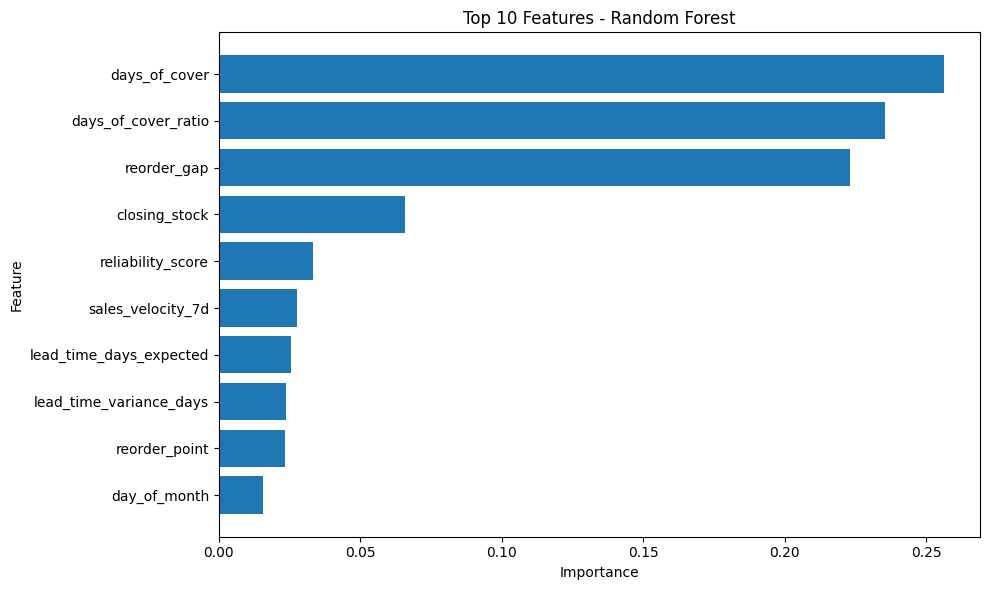

In [33]:
# Plot top 10 features

top_features = feature_importance.head(10)

plt.figure(figsize=(10, 6))
plt.barh(
    top_features["Feature"][::-1],
    top_features["Importance"][::-1]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 10 Features - Random Forest")
plt.tight_layout()
plt.show()

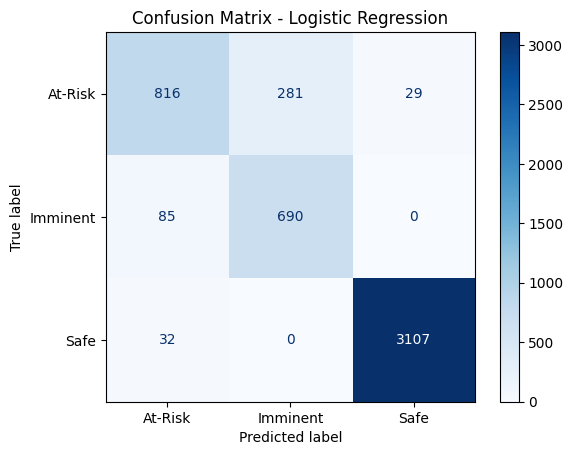

In [34]:
# STEP 8: CONFUSION MATRICES

from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Logistic Regression
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_logistic,
    cmap="Blues"
)

plt.title("Confusion Matrix - Logistic Regression")
plt.show()

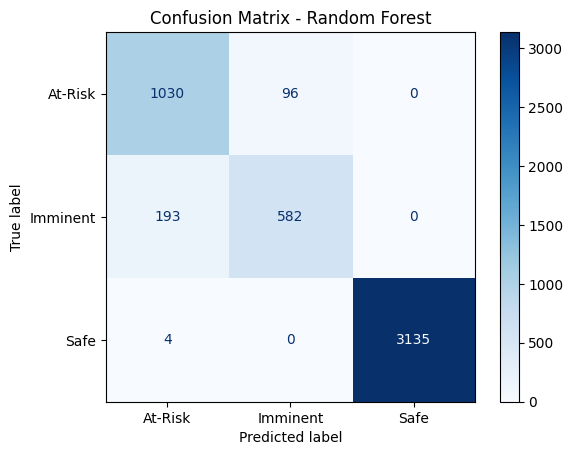

In [35]:
# Random Forest

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_rf,
    cmap="Blues"
)

plt.title("Confusion Matrix - Random Forest")
plt.show()

In [36]:
# STEP 9: FINAL MODEL COMPARISON

from sklearn.metrics import accuracy_score, f1_score, recall_score
import pandas as pd

comparison = pd.DataFrame({
    "Model": [
        "Majority Baseline",
        "Logistic Regression",
        "Random Forest"
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred_baseline),
        accuracy_score(y_test, y_pred_logistic),
        accuracy_score(y_test, y_pred_rf)
    ],
    "Macro F1": [
        f1_score(y_test, y_pred_baseline, average="macro"),
        f1_score(y_test, y_pred_logistic, average="macro"),
        f1_score(y_test, y_pred_rf, average="macro")
    ],
    "Imminent Recall": [
        recall_score(y_test, y_pred_baseline, labels=["Imminent"], average="macro"),
        recall_score(y_test, y_pred_logistic, labels=["Imminent"], average="macro"),
        recall_score(y_test, y_pred_rf, labels=["Imminent"], average="macro")
    ]
})

display(comparison.round(3))

,Model,Accuracy,Macro F1,Imminent Recall
0,Majority Baseline,0.623,0.256,0.000
1,Logistic Regression,0.915,0.858,0.890
2,Random Forest,0.942,0.892,0.751


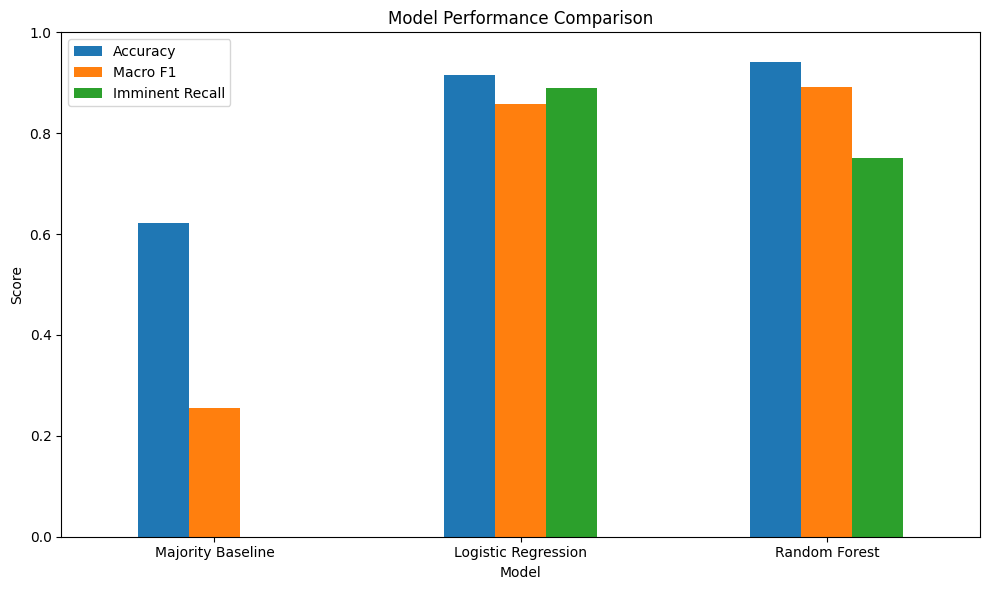

In [37]:
# STEP 10: MODEL PERFORMANCE VISUALIZATION

import matplotlib.pyplot as plt

comparison_plot = comparison.set_index("Model")[
    ["Accuracy", "Macro F1", "Imminent Recall"]
]

comparison_plot.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.xlabel("Model")
plt.xticks(rotation=0)
plt.ylim(0, 1)
plt.legend()
plt.tight_layout()
plt.show()